In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
import plotly.express as px
import math

In [2]:
df = pd.read_csv('IoTPond11.csv')
df.head()

,created_at,entry_id,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Population,Lenght,Weight
0,2021-06-25 15:14:07 CET,1,27.0625,100,22.562,8.20213,12151.86328,1061,50,14.12,33.8
1,2021-06-25 15:14:26 CET,2,27.1250,100,20.493,8.19759,15100.59473,1050,50,14.12,33.8
2,2021-06-25 15:15:42 CET,3,27.1250,100,12.555,8.20213,42010.77344,1039,50,14.12,33.8
3,2021-06-25 15:16:01 CET,4,27.0625,100,17.403,8.19759,21075.64453,1037,50,14.12,33.8
4,2021-06-25 15:16:21 CET,5,27.1250,100,22.765,8.21121,62079.92578,1039,50,14.12,33.8


In [3]:
print(df.isnull().sum())

created_at         0
entry_id           0
TEMPERATURE        0
TURBIDITY          0
DISOLVED OXYGEN    0
pH                 0
AMMONIA            1
NITRATE            0
Population         0
Lenght             0
Weight             0
dtype: int64


In [4]:
df['AMMONIA'].fillna(df['AMMONIA'].mean(), inplace=True)


In [5]:
df.drop(columns=['entry_id','Population'],axis=1,inplace=True)

In [6]:
df.describe()

,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Lenght,Weight
count,3165.000000,3165.000000,3165.000000,3165.000000,3.165000e+03,3165.000000,3165.000000,3165.000000
mean,24.415166,89.360821,4.560476,6.523293,6.118588e+08,583.723223,36.992305,513.557858
std,15.807021,25.081863,5.702163,2.034633,1.373257e+10,226.325204,10.938499,247.249547
min,-127.000000,-95.000000,0.000000,1.288530,0.000000e+00,0.000000,14.120000,33.800000
25%,25.437500,100.000000,0.000000,7.230690,0.000000e+00,576.000000,41.957860,625.885700
50%,26.125000,100.000000,1.293000,7.239770,0.000000e+00,624.000000,41.957860,625.885700
75%,26.812500,100.000000,8.361000,7.244310,1.775144e+03,654.000000,42.969290,644.357100
max,27.375000,100.000000,33.917000,15.451660,4.270000e+11,2165.000000,44.650000,701.000000


In [7]:
df.columns

Index(['created_at', 'TEMPERATURE', 'TURBIDITY', 'DISOLVED OXYGEN', 'pH',
       'AMMONIA', 'NITRATE', 'Lenght', 'Weight'],
      dtype='object')

In [8]:
df.shape

(3165, 9)

In [9]:
df['created_at'] = pd.to_datetime(df['created_at'], infer_datetime_format=True, utc=True)

In [10]:
df['created_at'] = pd.to_datetime(df.created_at)

#split columns
df["Date"] = df["created_at"].dt.day
df["month"] = df["created_at"].dt.month
df['year']=df['created_at'].dt.year
df['hour']=df['created_at'].dt.hour
df['minutes']=df['created_at'].dt.minute
df['seconds']=df['created_at'].dt.second

In [11]:
df.head()

,created_at,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Lenght,Weight,Date,month,year,hour,minutes,seconds
0,2021-06-25 15:14:07+00:00,27.0625,100,22.562,8.20213,12151.86328,1061,14.12,33.8,25,6,2021,15,14,7
1,2021-06-25 15:14:26+00:00,27.1250,100,20.493,8.19759,15100.59473,1050,14.12,33.8,25,6,2021,15,14,26
2,2021-06-25 15:15:42+00:00,27.1250,100,12.555,8.20213,42010.77344,1039,14.12,33.8,25,6,2021,15,15,42
3,2021-06-25 15:16:01+00:00,27.0625,100,17.403,8.19759,21075.64453,1037,14.12,33.8,25,6,2021,15,16,1
4,2021-06-25 15:16:21+00:00,27.1250,100,22.765,8.21121,62079.92578,1039,14.12,33.8,25,6,2021,15,16,21


In [12]:
df.drop(["created_at"], axis = 1, inplace = True)

In [13]:
 df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Date'] = pd.to_numeric(df['Date'])

In [14]:
 df['month'] = pd.to_datetime(df['month'], errors='coerce')

df['month'] = pd.to_numeric(df['month'])

In [15]:
 df['year'] = pd.to_datetime(df['year'], errors='coerce')

df['year'] = pd.to_numeric(df['year'])

In [16]:
df['hour'] = pd.to_datetime(df['hour'], errors='coerce')

df['hour'] = pd.to_numeric(df['hour'])

In [17]:
df['minutes'] = pd.to_datetime(df['minutes'], errors='coerce')

df['minutes'] = pd.to_numeric(df['minutes'])

In [18]:
df['seconds'] = pd.to_datetime(df['seconds'], errors='coerce')

df['seconds'] = pd.to_numeric(df['seconds'])

In [19]:
df.fillna(df.mean(), inplace=True)
df.replace([np.inf, -np.inf], 1e-9, inplace=True)

In [20]:
for i in range(len(df)):
    if df.loc[i, "TEMPERATURE"] < 20 or df.loc[i, "TEMPERATURE"] > 30:
        df.loc[i, "TEMPERATURE"] = df.loc[i-1, "TEMPERATURE"]

In [21]:
for i in range(1,len(df)):
    if df.loc[i, "pH"] < 6 or df.loc[i, "pH"] > 8.5:
        df.loc[i, "pH"] = df.loc[i-1,'pH']

In [22]:
df.at[0,'DISOLVED OXYGEN']=10

In [23]:
for i in range(1,len(df)):
    if df.loc[i, "DISOLVED OXYGEN"] < 5 or df.loc[i, "DISOLVED OXYGEN"] > 20:
        df.loc[i, "DISOLVED OXYGEN"] = df.loc[i-1, "DISOLVED OXYGEN"]

In [24]:
df["AMMONIA"] = np.log(df["AMMONIA"]) / 10.0
df["AMMONIA"] = df["AMMONIA"].abs()


In [25]:
df["NITRATE"] = df["NITRATE"].apply(np.sqrt)

In [27]:
for i in range(1,len(df)):
    if df.loc[i, "TURBIDITY"] < 0:
        df.loc[i, "TURBIDITY"] = df.loc[i-1,'TURBIDITY']

In [26]:
df.describe()

,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Lenght,Weight,Date,month,year,hour,minutes,seconds
count,3165.00000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000,3165.000000
mean,26.07581,89.360821,7.598412,7.112053,inf,23.530730,36.992305,513.557858,12.095735,7.109005,2021.012006,2.753555,5.715324,5.885624
std,0.78203,25.081863,3.150238,0.431772,NaN,5.480646,10.938499,247.249547,4.433096,1.848342,0.108931,6.524140,13.541929,14.121231
min,23.50000,-95.000000,5.063000,6.291020,0.006229,0.000000,14.120000,33.800000,1.000000,1.000000,2021.000000,0.000000,0.000000,0.000000
25%,25.50000,100.000000,5.201000,7.230690,1.005002,24.000000,41.957860,625.885700,11.000000,7.000000,2021.000000,0.000000,0.000000,0.000000
50%,26.18750,100.000000,6.411000,7.239770,NaN,24.979992,41.957860,625.885700,11.000000,7.000000,2021.000000,0.000000,0.000000,0.000000
75%,26.81250,100.000000,8.640000,7.244310,NaN,25.573424,42.969290,644.357100,12.000000,7.000000,2021.000000,0.000000,0.000000,0.000000
max,27.37500,100.000000,19.958000,8.238450,inf,46.529560,44.650000,701.000000,31.000000,12.000000,2022.000000,23.000000,59.000000,59.000000


In [28]:
columns=df.columns.tolist()
columns=columns[-6:]+columns[0:-6]
df=df[columns]

In [29]:
df.head()

,Date,month,year,hour,minutes,seconds,TEMPERATURE,TURBIDITY,DISOLVED OXYGEN,pH,AMMONIA,NITRATE,Lenght,Weight
0,25,6,2021,15,14,7,27.0625,100,10.000,8.20213,0.940524,32.572995,14.12,33.8
1,25,6,2021,15,14,26,27.1250,100,10.000,8.19759,0.962249,32.403703,14.12,33.8
2,25,6,2021,15,15,42,27.1250,100,12.555,8.20213,1.064568,32.233523,14.12,33.8
3,25,6,2021,15,16,1,27.0625,100,17.403,8.19759,0.995587,32.202484,14.12,33.8
4,25,6,2021,15,16,21,27.1250,100,17.403,8.21121,1.103618,32.233523,14.12,33.8


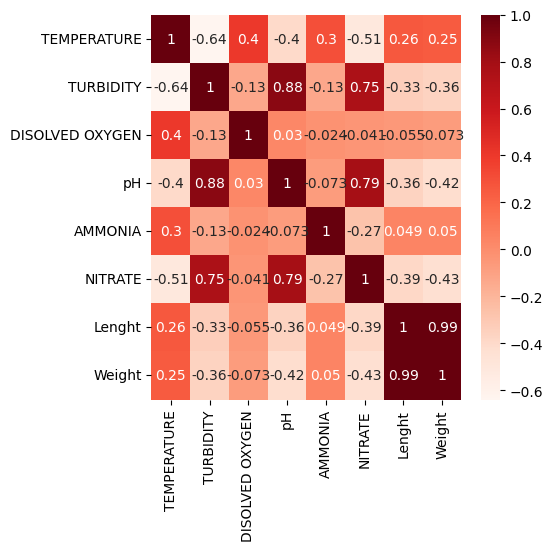

In [30]:
#creating a heatmap to show the correlation between the features
plt.figure(figsize=(5, 5))
x=df.iloc[:,6:]
cor = x.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)
plt.show()

In [31]:
df.to_csv('pp11.csv', index=False)